# Diffusion Models, DDPM & Stable Diffusion

>This Notebook is a from-scratch, pixel-space conditional DDPM with CLIP text conditioning and cross-attention. It is Stable-Diffusion-style in its conditioning/U-Net concepts, but it is not literally Stable Diffusion, because actual Stable Diffusion performs diffusion in a VAE latent space. Moreover if you want a more better result it is advised to train for **50+ Epochs**.

## Importing the libraries

In [ ]:
import os
import math
import random
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import kagglehub
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from torchvision import transforms
from torchvision.utils import make_grid, save_image

from transformers import CLIPTokenizer, CLIPTextModel

## Configuring the device

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: Tesla T4


## Configurations

In [ ]:
IMAGE_SIZE = 64
BATCH_SIZE = 16
NUM_WORKERS = 0
EPOCHS = 10

LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4

NUM_TIMESTEPS = 1000
BASE_CHANNELS = 64
TIME_EMBED_DIM = 256
TEXT_EMBED_DIM = 768
MAX_TEXT_LENGTH = 77

GUIDANCE_SCALE = 1.0
CFG_DROPOUT_PROB = 0.15
EMA_DECAY = 0.999

GRADIENT_CLIP = 1.0
MAX_TRAIN_IMAGES = 8000
SAVE_EVERY = 5

CHECKPOINT_DIR = "/kaggle/working/diffusion_checkpoints"
GENERATED_DIR = "/kaggle/working/generated_images"

os.makedirs(CHECKPOINT_DIR, exist_ok = True)
os.makedirs(GENERATED_DIR, exist_ok = True)

## Importing the Kaggle dataset

In [ ]:
dataset_path = kagglehub.dataset_download("nunenuh/flickr8k")
print("Dataset path:")
print(dataset_path)

## Exploring the dataset

In [ ]:
for root, dirs, files in os.walk(dataset_path):

    level = root.replace(dataset_path, "").count(os.sep)
    indent = "    " * level
    print(f"{indent}{os.path.basename(root)}/")
    subindent = "    " * (level + 1)

    for file in files[:10]:
        print(f"{subindent}{file}")

## Finding image files

In [ ]:
IMAGE_EXTENSIONS = (".jpg", ".jpeg", ".png", ".bmp", ".webp")
image_files = []

for root, dirs, files in os.walk(dataset_path):
    for file in files:
        if file.lower().endswith(IMAGE_EXTENSIONS):

            image_files.append(
                os.path.join(root, file)
            )

print("Images found:", len(image_files))

Images found: 8091


## Finding the caption file

In [ ]:
text_files = []

for root, dirs, files in os.walk(dataset_path):
    for file in files:
        if file.lower().endswith((".txt", ".csv")):

            text_files.append(
                os.path.join(root, file)
            )

print("Text files:")

for path in text_files:
    print(path)

## Selecting Flickr8k captions

In [ ]:
caption_file = None

for path in text_files:
    filename = os.path.basename(path).lower()

    if ("caption" in filename or "token" in filename):
        caption_file = path
        break

print("Caption file:")
print(caption_file)

## Reading captions

In [ ]:
with open(caption_file, "r", encoding = "utf-8", errors="ignore") as file:

    caption_lines = file.readlines()

print("Caption lines:", len(caption_lines))
print(caption_lines[:5])

## Parsing captions

In [ ]:
records = []

for line in caption_lines:

    line = line.strip()

    if not line:
        continue

    if "|" in line:
      parts = line.split("|")

      if len(parts) >= 3:

          image_name = parts[0].strip()
          caption_number = parts[1].strip()
          caption = "|".join(parts[2:]).strip()

          records.append({
              "image_name": image_name,
              "caption_number": caption_number,
              "caption": caption
          })

          continue

    if "," in line:

        parts = line.split(",", 1)

        if len(parts) == 2:

            image_name = parts[0].strip()
            caption = parts[1].strip()

            records.append({
                "image_name": image_name,
                "caption_number": "0",
                "caption": caption
            })

## Creating caption dataframe

In [ ]:
captions_df = pd.DataFrame(records)

print(captions_df.head())
print(captions_df.shape)

## Cleaning captions

In [ ]:
captions_df["image_name"] = captions_df["image_name"].astype(str).str.strip()
captions_df["caption"] = captions_df["caption"].astype(str).str.strip()

captions_df = captions_df[
    captions_df["caption"].str.len() > 0
]

image_lookup = {
    os.path.basename(path): path
    for path in image_files
}

captions_df = captions_df[
    captions_df["image_name"].isin(
        image_lookup.keys()
    )
]

captions_df = captions_df.reset_index(drop = True)
print("Valid caption pairs:", len(captions_df))

Valid caption pairs: 40455


## Creating image paths

In [ ]:
captions_df["image_path"] = captions_df["image_name"].map(image_lookup)

## Dataset statistics

In [ ]:
print("Unique images:", captions_df["image_name"].nunique())
print("Caption pairs:", len(captions_df))
print(captions_df["caption"].iloc[:10].tolist())

## Dataset Preview

In [ ]:
preview_df = captions_df.sample(12)

fig, axes = plt.subplots(3, 4, figsize = (14, 10))

for ax, (_, row) in zip(axes.flatten(), preview_df.iterrows()):

    image = Image.open(row["image_path"]).convert("RGB")
    ax.imshow(image)
    ax.set_title(row["caption"], fontsize = 8)
    ax.axis("off")

plt.tight_layout()
plt.show()

## Train / Validation Split

In [ ]:
unique_images = captions_df["image_name"].unique()
random.shuffle(unique_images)

split_index = int(len(unique_images) * 0.9)

train_images = unique_images[:split_index]
validation_images = unique_images[split_index:]

train_df = captions_df[captions_df["image_name"].isin(train_images)].reset_index(drop = True)
validation_df = captions_df[captions_df["image_name"].isin(validation_images)].reset_index(drop = True)

print("Training images:", len(train_images))
print("Validation images:", len(validation_images))

print("Training pairs:", len(train_df))
print("Validation pairs:", len(validation_df))

Training images: 7281
Validation images: 810
Training pairs: 36405
Validation pairs: 4050


## Image Transformations

In [ ]:
train_transform = transforms.Compose([

    transforms.Resize(IMAGE_SIZE),
    transforms.RandomCrop(IMAGE_SIZE),
    transforms.RandomHorizontalFlip(p = 0.5),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.5, 0.5, 0.5],
        [0.5, 0.5, 0.5]
    )
])

In [ ]:
validation_transform = transforms.Compose([

    transforms.Resize(IMAGE_SIZE),
    transforms.CenterCrop(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.5, 0.5, 0.5],
        [0.5, 0.5, 0.5]
    )
])

## Flickr8k Dataset

In [ ]:
class Flickr8kDiffusionDataset(Dataset):

    def __init__(self, dataframe, transform = None):

        self.dataframe = (dataframe.reset_index(drop = True))
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):

        row = self.dataframe.iloc[index]
        image = Image.open(row["image_path"]).convert("RGB")

        if self.transform:
            image = self.transform(image)

        caption = row["caption"]

        return {
            "image": image,
            "caption": caption,
            "image_name": row["image_name"]
        }

## Creating datasets

In [ ]:
train_dataset = Flickr8kDiffusionDataset(
    train_df,
    transform = train_transform
)

validation_dataset = Flickr8kDiffusionDataset(
    validation_df,
    transform = validation_transform
)

print("Train dataset:", len(train_dataset))
print("Validation dataset:", len(validation_dataset))

Train dataset: 36405
Validation dataset: 4050


## Creating DataLoader

In [ ]:
train_loader = DataLoader(
    train_dataset,
    batch_size = BATCH_SIZE,
    shuffle = True,
    num_workers = NUM_WORKERS,
    pin_memory = True,
    drop_last = True
)

validation_loader = DataLoader(
    validation_dataset,
    batch_size = BATCH_SIZE,
    shuffle = False,
    num_workers = NUM_WORKERS,
    pin_memory = True
)

print("Training batches:", len(train_loader))
print("Validation batches:",len(validation_loader))

Training batches: 2275
Validation batches: 254


## CLIP Tokenizer

In [ ]:
CLIP_MODEL_NAME = "openai/clip-vit-large-patch14"
tokenizer = CLIPTokenizer.from_pretrained(CLIP_MODEL_NAME)

## CLIP Text Encoder

In [ ]:
text_encoder = CLIPTextModel.from_pretrained(CLIP_MODEL_NAME)
text_encoder = text_encoder.to(device)
text_encoder.eval()

for parameter in text_encoder.parameters():
    parameter.requires_grad = False

## Text Tokenization

In [ ]:
def tokenize_prompts(prompts):

    tokens = tokenizer(
        list(prompts),
        padding = "max_length",
        truncation = True,
        max_length = MAX_TEXT_LENGTH,
        return_tensors = "pt"
    )

    return {key: value.to(device) for key, value in tokens.items()}

## Text Encoding

In [ ]:
@torch.no_grad()
def encode_prompts(prompts):

    tokens = tokenize_prompts(prompts)

    outputs = text_encoder(
        input_ids = tokens[
            "input_ids"
        ],
        attention_mask = tokens[
            "attention_mask"
        ]
    )

    return outputs.last_hidden_state

## Testing Text Embedding

In [ ]:
test_prompts = [
    "a dog running through a field",
    "a child playing in the park",
    "a man riding a bicycle",
    "a group of people walking"
]

test_embeddings = encode_prompts(test_prompts)
print(test_embeddings.shape)

torch.Size([4, 77, 768])


## Diffusion Schedule

In [ ]:
def cosine_beta_schedule(timesteps, s = 0.008):

    steps = timesteps + 1
    x = torch.linspace(0, timesteps, steps)

    alpha_cumprod = torch.cos(((x / timesteps) + s) / (1 + s) * math.pi / 2) ** 2
    alpha_cumprod = (alpha_cumprod / alpha_cumprod[0])

    betas = 1 - (alpha_cumprod[1:] / alpha_cumprod[:-1])

    return torch.clip(betas, 0.0001, 0.999)

## Diffusion Constants

In [ ]:
betas = cosine_beta_schedule(NUM_TIMESTEPS).to(device)

alphas = 1.0 - betas

alphas_cumprod = torch.cumprod(alphas, dim = 0)
alphas_cumprod_prev = F.pad(alphas_cumprod[:-1], (1, 0), value = 1.0)

sqrt_alphas_cumprod = torch.sqrt(alphas_cumprod)
sqrt_one_minus_alphas_cumprod = torch.sqrt(1.0 - alphas_cumprod)
sqrt_recip_alphas = torch.sqrt(1.0 / alphas)

posterior_variance = (betas * (1.0 - alphas_cumprod_prev) / (1.0 - alphas_cumprod))

## Visualising Diffusion Schedule

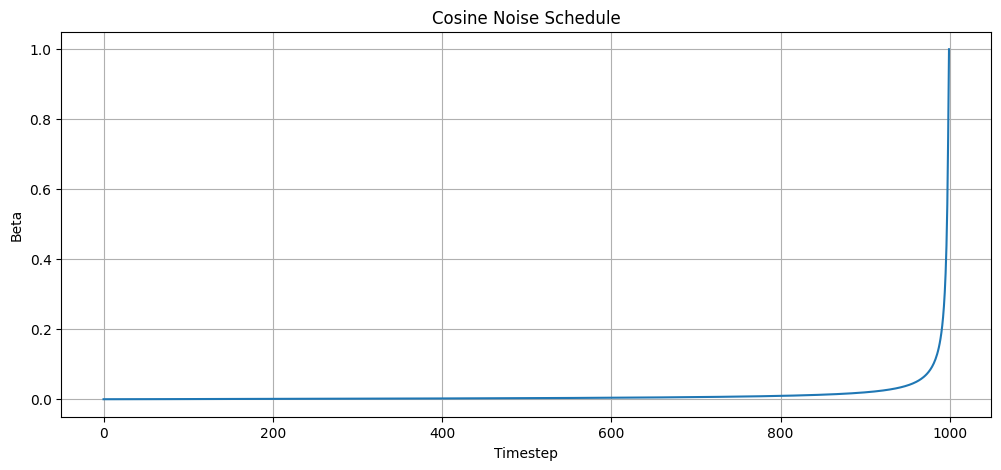

In [ ]:
plt.figure(figsize = (12, 5))
plt.plot(betas.detach().cpu().numpy())
plt.xlabel("Timestep")
plt.ylabel("Beta")
plt.title("Cosine Noise Schedule")
plt.grid()
plt.show()

## Tensor Extraction

In [ ]:
def extract(values, timesteps, shape):

    batch_size = timesteps.shape[0]
    out = values.gather(-1, timesteps)

    return out.reshape(batch_size, *((1,) * (len(shape) - 1)))

## Forward Diffusion

In [ ]:
def q_sample(x_start, timesteps, noise = None):

    if noise is None:
        noise = torch.randn_like(x_start)

    sqrt_alpha = extract(
        sqrt_alphas_cumprod,
        timesteps,
        x_start.shape
    )

    sqrt_one_minus_alpha = extract(
        sqrt_one_minus_alphas_cumprod,
        timesteps,
        x_start.shape
    )

    return (sqrt_alpha * x_start + sqrt_one_minus_alpha * noise)

## Visualising Forward Diffusion

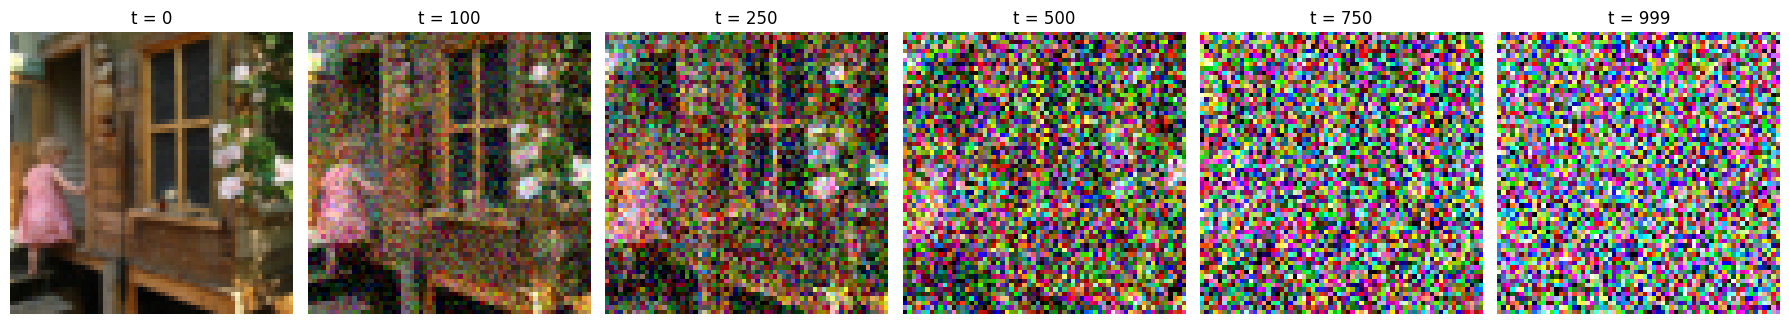

In [ ]:
sample_image = train_dataset[0]["image"].unsqueeze(0).to(device)

visualization_timesteps = [0, 100, 250, 500, 750, 999]
fig, axes = plt.subplots(1, len(visualization_timesteps), figsize = (18, 4))

for ax, timestep in zip(axes, visualization_timesteps):

    t = torch.tensor([timestep], device = device)
    noisy_image = q_sample(sample_image, t)

    image = noisy_image[0].detach().cpu().permute(1, 2, 0).numpy()
    image = (image * 0.5 + 0.5)
    image = np.clip(image, 0, 1)

    ax.imshow(image)
    ax.set_title(f"t = {timestep}")
    ax.axis("off")

plt.tight_layout()
plt.show()

## Sinusoidal Time Embedding

In [ ]:
class SinusoidalTimeEmbedding(nn.Module):

    def __init__(self, dimension):

        super().__init__()
        self.dimension = dimension

    def forward(self, time):

        device = time.device
        half_dimension = self.dimension // 2

        exponent = math.log(10000) / (half_dimension - 1)
        exponent = torch.exp(
            torch.arange(
                half_dimension,
                device=device
            ) * -exponent
        )

        embeddings = (time[:, None] * exponent[None, :])
        embeddings = torch.cat([embeddings.sin(), embeddings.cos()], dim = -1)

        return embeddings

## Group Normalization

In [ ]:
def get_num_groups(channels):

    for groups in [32, 16, 8, 4, 2, 1]:

        if channels % groups == 0:
            return groups

    return 1

## Residual Block

In [ ]:
class ResidualBlock(nn.Module):

    def __init__(self, in_channels, out_channels, time_dim, text_dim):

        super().__init__()

        self.norm1 = nn.GroupNorm(
            get_num_groups(in_channels),
            in_channels
        )

        self.conv1 = nn.Conv2d(
            in_channels,
            out_channels,
            3,
            padding = 1
        )

        self.time_projection = nn.Sequential(
            nn.SiLU(),
            nn.Linear(time_dim, out_channels)
        )

        self.text_projection = nn.Linear(
            text_dim,
            out_channels
        )

        self.norm2 = nn.GroupNorm(
            get_num_groups(out_channels),
            out_channels
        )

        self.conv2 = nn.Conv2d(
            out_channels,
            out_channels,
            3,
            padding = 1
        )

        if in_channels != out_channels:
            self.skip = nn.Conv2d(
                in_channels,
                out_channels,
                1
            )
        else:
            self.skip = nn.Identity()

    def forward(self, x, time_embedding, text_embedding):

        residual = self.skip(x)
        h = self.norm1(x)
        h = F.silu(h)
        h = self.conv1(h)

        time_condition = self.time_projection(time_embedding)[:, :, None, None]

        text_condition = (
            text_embedding.mean(
                dim = 1
            )
        )

        text_condition = self.text_projection(text_condition)[:, :, None, None]

        h = h + time_condition + text_condition
        h = self.norm2(h)
        h = F.silu(h)
        h = self.conv2(h)

        return h + residual

## Cross Attention

In [ ]:
class CrossAttention(nn.Module):

    def __init__(self, channels, context_dim, heads = 8):

        super().__init__()
        assert channels % heads == 0

        self.channels = channels
        self.heads = heads
        self.head_dim = channels // heads

        self.norm = nn.GroupNorm(
            get_num_groups(channels),
            channels
        )

        self.to_q = nn.Linear(
            channels,
            channels,
            bias = False
        )

        self.to_k = nn.Linear(
            context_dim,
            channels,
            bias = False
        )

        self.to_v = nn.Linear(
            context_dim,
            channels,
            bias = False
        )

        self.to_out = nn.Linear(
            channels,
            channels
        )

    def forward(self, x, context):

        batch_size, channels, height, width = x.shape
        residual = x

        x = self.norm(x)
        x = x.permute(0, 2, 3, 1)

        x = x.reshape(
            batch_size,
            height * width,
            channels
        )

        q = self.to_q(x)
        k = self.to_k(context)
        v = self.to_v(context)

        q = q.reshape(
            batch_size,
            -1,
            self.heads,
            self.head_dim
        )

        k = k.reshape(
            batch_size,
            -1,
            self.heads,
            self.head_dim
        )

        v = v.reshape(
            batch_size,
            -1,
            self.heads,
            self.head_dim
        )

        q = q.transpose(1, 2)
        k = k.transpose(1, 2)
        v = v.transpose(1, 2)

        attention = torch.matmul(q, k.transpose(-1, -2))
        attention = (attention / math.sqrt(self.head_dim))

        attention = torch.softmax(
            attention,
            dim = -1
        )

        output = torch.matmul(
            attention,
            v
        )

        output = output.transpose(1, 2)

        output = output.reshape(
            batch_size,
            height * width,
            channels
        )

        output = self.to_out(output)

        output = output.reshape(
            batch_size,
            height,
            width,
            channels
        )

        output = output.permute(0, 3, 1, 2)

        return output + residual

## Downsample

In [ ]:
class Downsample(nn.Module):

    def __init__(self, channels):

        super().__init__()
        self.conv = nn.Conv2d(channels, channels, 3, stride = 2, padding = 1)

    def forward(self, x):
        return self.conv(x)

## Upsample

In [ ]:
class Upsample(nn.Module):

    def __init__(self, channels):

        super().__init__()
        self.conv = nn.Conv2d(channels, channels, 3, padding = 1)

    def forward(self, x):

        x = F.interpolate(
            x,
            scale_factor = 2,
            mode = "nearest"
        )

        return self.conv(x)

## Conditional U-Net

In [ ]:
class ConditionalUNet(nn.Module):

    def __init__(self, in_channels = 3, out_channels = 3, base_channels = 64, time_dim = 256, text_dim = 768):

        super().__init__()

        self.time_embedding = nn.Sequential(

            SinusoidalTimeEmbedding(time_dim),
            nn.Linear(time_dim, time_dim),
            nn.SiLU(),
            nn.Linear(time_dim, time_dim)
        )

        self.input = nn.Conv2d(
            in_channels,
            base_channels,
            3,
            padding = 1
        )

        self.down1 = ResidualBlock(
            base_channels,
            base_channels,
            time_dim,
            text_dim
        )

        self.attn1 = CrossAttention(
            base_channels,
            text_dim
        )

        self.downsample1 = Downsample(
            base_channels
        )

        self.down2 = ResidualBlock(
            base_channels,
            base_channels * 2,
            time_dim,
            text_dim
        )

        self.attn2 = CrossAttention(
            base_channels * 2,
            text_dim
        )

        self.downsample2 = Downsample(
            base_channels * 2
        )

        self.down3 = ResidualBlock(
            base_channels * 2,
            base_channels * 4,
            time_dim,
            text_dim
        )

        self.attn3 = CrossAttention(
            base_channels * 4,
            text_dim
        )

        self.downsample3 = Downsample(
            base_channels * 4
        )

        self.middle1 = ResidualBlock(
            base_channels * 4,
            base_channels * 8,
            time_dim,
            text_dim
        )

        self.middle_attention = CrossAttention(
            base_channels * 8,
            text_dim
        )

        self.middle2 = ResidualBlock(
            base_channels * 8,
            base_channels * 8,
            time_dim,
            text_dim
        )

        self.upsample3 = Upsample(
            base_channels * 8
        )

        self.up3 = ResidualBlock(
            base_channels * 12,
            base_channels * 4,
            time_dim,
            text_dim
        )

        self.up_attention3 = CrossAttention(
            base_channels * 4,
            text_dim
        )

        self.upsample2 = Upsample(
            base_channels * 4
        )

        self.up2 = ResidualBlock(
            base_channels * 6,
            base_channels * 2,
            time_dim,
            text_dim
        )

        self.up_attention2 = CrossAttention(
            base_channels * 2,
            text_dim
        )

        self.upsample1 = Upsample(
            base_channels * 2
        )

        self.up1 = ResidualBlock(
            base_channels * 3,
            base_channels,
            time_dim,
            text_dim
        )

        self.up_attention1 = CrossAttention(
            base_channels,
            text_dim
        )

        self.output_norm = nn.GroupNorm(
            get_num_groups(base_channels),
            base_channels
        )

        self.output = nn.Conv2d(
            base_channels,
            out_channels,
            3,
            padding = 1
        )

    def forward(self, x, timestep, text_embedding):

        time_embedding = (self.time_embedding(timestep))

        x = self.input(x)

        d1 = self.down1(
            x,
            time_embedding,
            text_embedding
        )

        d1 = self.attn1(
            d1,
            text_embedding
        )

        d2_input = self.downsample1(d1)

        d2 = self.down2(
            d2_input,
            time_embedding,
            text_embedding
        )

        d2 = self.attn2(
            d2,
            text_embedding
        )

        d3_input = self.downsample2(d2)

        d3 = self.down3(
            d3_input,
            time_embedding,
            text_embedding
        )

        d3 = self.attn3(
            d3,
            text_embedding
        )

        middle = self.downsample3(d3)

        middle = self.middle1(
            middle,
            time_embedding,
            text_embedding
        )

        middle = self.middle_attention(
            middle,
            text_embedding
        )

        middle = self.middle2(
            middle,
            time_embedding,
            text_embedding
        )

        u3 = self.upsample3(middle)

        u3 = torch.cat([u3, d3], dim = 1)

        u3 = self.up3(
            u3,
            time_embedding,
            text_embedding
        )

        u3 = self.up_attention3(
            u3,
            text_embedding
        )

        u2 = self.upsample2(u3)

        u2 = torch.cat([u2, d2], dim = 1)

        u2 = self.up2(
            u2,
            time_embedding,
            text_embedding
        )

        u2 = self.up_attention2(
            u2,
            text_embedding
        )

        u1 = self.upsample1(u2)

        u1 = torch.cat([u1, d1], dim = 1)

        u1 = self.up1(
            u1,
            time_embedding,
            text_embedding
        )

        u1 = self.up_attention1(
            u1,
            text_embedding
        )

        output = self.output_norm(u1)

        output = F.silu(
            output
        )

        output = self.output(
            output
        )

        return output

## Creating the model

In [ ]:
model = ConditionalUNet(
    in_channels = 3,
    out_channels = 3,
    base_channels = BASE_CHANNELS,
    time_dim = TIME_EMBED_DIM,
    text_dim = TEXT_EMBED_DIM
).to(device)

ema_model = ConditionalUNet(
    in_channels = 3,
    out_channels = 3,
    base_channels = BASE_CHANNELS,
    time_dim = TIME_EMBED_DIM,
    text_dim = TEXT_EMBED_DIM
).to(device)

ema_model.load_state_dict(model.state_dict())

<All keys matched successfully>

In [ ]:
for parameter in ema_model.parameters():
    parameter.requires_grad = False

@torch.no_grad()
def update_ema(ema_model, model, decay = EMA_DECAY):
    for ema_param, param in zip(ema_model.parameters(), model.parameters()):
        ema_param.mul_(decay).add_(param, alpha = 1 - decay)

## Number of parameters

In [ ]:
total_parameters = sum(parameter.numel() for parameter in model.parameters())
trainable_parameters = sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad)

print(f"Total parameters: {total_parameters:,}")
print(f"Trainable parameters: {trainable_parameters:,}")

Total parameters: 21,990,083
Trainable parameters: 21,990,083


## Model Forward Test

In [ ]:
dummy_images = torch.randn(2, 3, IMAGE_SIZE, IMAGE_SIZE, device = device)
dummy_timesteps = torch.randint(0, NUM_TIMESTEPS, (2,), device = device)

dummy_text = encode_prompts([
    "a dog running",
    "a person riding a bicycle"
])

with torch.no_grad():

    dummy_output = model(
        dummy_images,
        dummy_timesteps,
        dummy_text
    )

print("Input:", dummy_images.shape)
print("Output:", dummy_output.shape)

Input: torch.Size([2, 3, 64, 64])
Output: torch.Size([2, 3, 64, 64])


## Optimizer

In [ ]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr = LEARNING_RATE,
    weight_decay = WEIGHT_DECAY
)

## Learning Rate Scheduler

In [ ]:
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max = EPOCHS
)

## Mixed Precision

In [ ]:
use_amp = torch.cuda.is_available()
scaler = torch.amp.GradScaler("cuda", enabled = use_amp)

## Training Function

In [ ]:
def train_one_epoch(model, ema_model, loader, optimizer, scaler, epoch, uncond_prob = CFG_DROPOUT_PROB):

    model.train()
    total_loss = 0.0

    progress = tqdm(loader, desc = f"Epoch {epoch}")

    for batch in progress:

        images = batch["image"].to(device, non_blocking = True)

        captions = list(batch["caption"])
        captions = ["" if random.random() < uncond_prob else c for c in captions]

        batch_size = images.shape[0]

        timesteps = torch.randint(
            0,
            NUM_TIMESTEPS,
            (batch_size,),
            device = device
        ).long()

        noise = torch.randn_like(images)

        noisy_images = q_sample(
            images,
            timesteps,
            noise
        )

        with torch.no_grad():
            text_embeddings = encode_prompts(captions)

        optimizer.zero_grad(set_to_none = True)

        with torch.autocast(device_type = "cuda", enabled = use_amp):

            predicted_noise = model(
                noisy_images,
                timesteps,
                text_embeddings
            )

            loss = F.mse_loss(
                predicted_noise,
                noise
            )

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            GRADIENT_CLIP
        )

        scaler.step(optimizer)
        scaler.update()
        update_ema(ema_model, model)

        total_loss += loss.item()

        progress.set_postfix(
            loss = f"{loss.item():.5f}"
        )

    return total_loss / len(loader)

## Validation Function

In [ ]:
@torch.no_grad()
def validate(model, loader):

    model.eval()
    total_loss = 0.0

    for batch in tqdm(loader, desc = "Validation"):

        images = batch["image"].to(device, non_blocking = True)
        captions = batch["caption"]

        batch_size = images.shape[0]
        timesteps = torch.randint(
            0,
            NUM_TIMESTEPS,
            (batch_size,),
            device = device
        ).long()

        noise = torch.randn_like(images)

        noisy_images = q_sample(
            images,
            timesteps,
            noise
        )

        text_embeddings = encode_prompts(captions)

        predicted_noise = model(
            noisy_images,
            timesteps,
            text_embeddings
        )

        loss = F.mse_loss(
            predicted_noise,
            noise
        )

        total_loss += loss.item()

    return total_loss / len(loader)

## DDPM Reverse Process

In [ ]:
@torch.no_grad()
def predict_noise(model, x, timestep, text_embedding):
    return model(x, timestep, text_embedding)

In [ ]:
posterior_mean_coef1 = betas * torch.sqrt(alphas_cumprod_prev) / (1.0 - alphas_cumprod)
posterior_mean_coef2 = (1.0 - alphas_cumprod_prev) * torch.sqrt(alphas) / (1.0 - alphas_cumprod)

@torch.no_grad()
def p_sample(model, x, timestep, text_embedding):
    predicted_noise = predict_noise(model, x, timestep, text_embedding)

    sqrt_ac = extract(sqrt_alphas_cumprod, timestep, x.shape)
    sqrt_1m_ac = extract(sqrt_one_minus_alphas_cumprod, timestep, x.shape)

    x0_pred = (x - sqrt_1m_ac * predicted_noise) / sqrt_ac
    x0_pred = x0_pred.clamp(-1, 1)

    coef1 = extract(posterior_mean_coef1, timestep, x.shape)
    coef2 = extract(posterior_mean_coef2, timestep, x.shape)

    model_mean = coef1 * x0_pred + coef2 * x

    if timestep[0].item() == 0:
        return model_mean

    posterior_var = extract(posterior_variance, timestep, x.shape)

    return model_mean + torch.sqrt(posterior_var) * torch.randn_like(x)

## DDPM Sampling

In [ ]:
@torch.no_grad()
def sample_ddpm(model, prompts, image_size = IMAGE_SIZE):

    model.eval()
    batch_size = len(prompts)

    text_embeddings = encode_prompts(prompts)

    x = torch.randn(
        batch_size,
        3,
        image_size,
        image_size,
        device = device
    )

    for timestep in tqdm(
        reversed(range(NUM_TIMESTEPS)),
        total = NUM_TIMESTEPS,
        desc = "DDPM Sampling"
    ):

        timestep_tensor = torch.full(
            (batch_size,),
            timestep,
            device = device,
            dtype = torch.long
        )

        x = p_sample(
            model,
            x,
            timestep_tensor,
            text_embeddings
        )

    return (x.clamp(-1, 1) + 1) / 2

## Classifier-free Guidance

In [ ]:
@torch.no_grad()
def get_guidance_embeddings(prompts):

    conditional_embeddings = encode_prompts(prompts)
    unconditional_prompts = ["" for _ in prompts]
    unconditional_embeddings = encode_prompts(unconditional_prompts)

    return (unconditional_embeddings, conditional_embeddings)

## Guided Noise Prediction

In [ ]:
@torch.no_grad()
def guided_noise_prediction(
    model,
    x,
    timestep,
    unconditional_embeddings,
    conditional_embeddings,
    guidance_scale
):

    batch_size = x.shape[0]

    model_input = torch.cat(
        [x, x],
        dim=0
    )

    timestep_input = torch.cat(
        [timestep, timestep],
        dim=0
    )

    text_input = torch.cat(
        [
            unconditional_embeddings,
            conditional_embeddings
        ],
        dim=0
    )

    noise_prediction = model(
        model_input,
        timestep_input,
        text_input
    )

    unconditional_prediction = (
        noise_prediction[:batch_size]
    )

    conditional_prediction = (
        noise_prediction[batch_size:]
    )

    guided_prediction = (
        unconditional_prediction
        + guidance_scale
        * (
            conditional_prediction
            - unconditional_prediction
        )
    )

    return guided_prediction

## DDPM + CGF Sampling

In [ ]:
@torch.no_grad()
def sample_cfg(
    model,
    prompts,
    guidance_scale=1.0,
    image_size=IMAGE_SIZE
):

    model.eval()

    batch_size = len(prompts)

    (
        unconditional_embeddings,
        conditional_embeddings
    ) = get_guidance_embeddings(
        prompts
    )

    x = torch.randn(
        batch_size,
        3,
        image_size,
        image_size,
        device=device
    )

    for timestep in tqdm(
        reversed(range(NUM_TIMESTEPS)),
        total = NUM_TIMESTEPS,
        desc = "CFG Sampling"
    ):

        timestep_tensor = torch.full(
            (batch_size,),
            timestep,
            device = device,
            dtype = torch.long
        )

        predicted_noise = guided_noise_prediction(
            model,
            x,
            timestep_tensor,
            unconditional_embeddings,
            conditional_embeddings,
            guidance_scale
        )

        sqrt_ac = extract(
            sqrt_alphas_cumprod,
            timestep_tensor,
            x.shape
        )

        sqrt_one_minus_ac = extract(
            sqrt_one_minus_alphas_cumprod,
            timestep_tensor,
            x.shape
        )

        x0_pred = (x - sqrt_one_minus_ac * predicted_noise) / sqrt_ac
        x0_pred = x0_pred.clamp(-1.0, 1.0)

        coef1 = extract(
            posterior_mean_coef1,
            timestep_tensor,
            x.shape
        )

        coef2 = extract(
            posterior_mean_coef2,
            timestep_tensor,
            x.shape
        )

        model_mean = (
            coef1 * x0_pred
            + coef2 * x
        )

        if timestep == 0:
            x = model_mean

        else:
            posterior_var = extract(
                posterior_variance,
                timestep_tensor,
                x.shape
            )

            noise = torch.randn_like(x)
            x = model_mean + torch.sqrt(posterior_var) * noise

    return (x.clamp(-1, 1) + 1) / 2

## Fixed Evaluation Prompts

In [ ]:
evaluation_prompts = [
    "a dog running through a grassy field",
    "a child playing with a dog",
    "a man riding a bicycle",
    "a group of people walking outdoors",
    "a dog jumping in the air",
    "a person standing near a mountain"
]

## Training Configurations

In [ ]:
training_losses = []
validation_losses = []
best_validation_loss = float("inf")

## Training Loop

In [ ]:
for epoch in range(1, EPOCHS + 1):

    train_loss = train_one_epoch(
        model,
        ema_model,
        train_loader,
        optimizer,
        scaler,
        epoch
    )

    validation_loss = validate(
        model,
        validation_loader
    )

    training_losses.append(
        train_loss
    )

    validation_losses.append(
        validation_loss
    )

    scheduler.step()

    print()
    print(f"Epoch: {epoch}/{EPOCHS}")
    print(f"Train Loss: {train_loss:.6f}")
    print(f"Validation Loss: {validation_loss:.6f}")
    print(f"Learning Rate: {optimizer.param_groups[0]['lr']:.8f}")

    if validation_loss < best_validation_loss:

        best_validation_loss = (
            validation_loss
        )

        best_model_path = os.path.join(
            CHECKPOINT_DIR,
            "best_diffusion_model.pt"
        )

        torch.save(
            {
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "scheduler_state_dict": scheduler.state_dict(),
                "train_loss": train_loss,
                "validation_loss": validation_loss,
                "ema_state_dict": ema_model.state_dict(),
            },
            best_model_path
        )

        print("Best model saved")

    if epoch % SAVE_EVERY == 0:

        checkpoint_path = os.path.join(
            CHECKPOINT_DIR,
            f"checkpoint_epoch_{epoch}.pt"
        )

        torch.save(
            {
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "scheduler_state_dict": scheduler.state_dict(),
                "train_loss": train_loss,
                "validation_loss": validation_loss,
                "ema_state_dict": ema_model.state_dict(),
            },
            checkpoint_path
        )

Epoch 1:   0%|          | 0/2275 [00:00<?, ?it/s]

Validation:   0%|          | 0/254 [00:00<?, ?it/s]


Epoch: 1/10
Train Loss: 0.090026
Validation Loss: 0.064326
Learning Rate: 0.00009755
Best model saved


Epoch 2:   0%|          | 0/2275 [00:00<?, ?it/s]

Validation:   0%|          | 0/254 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/254 [00:00<?, ?it/s]


Epoch: 9/10
Train Loss: 0.053369
Validation Loss: 0.053617
Learning Rate: 0.00000245
Best model saved


Epoch 10:   0%|          | 0/2275 [00:00<?, ?it/s]

Validation:   0%|          | 0/254 [00:00<?, ?it/s]


Epoch: 10/10
Train Loss: 0.053203
Validation Loss: 0.052550
Learning Rate: 0.00000000
Best model saved


## Loss Curves

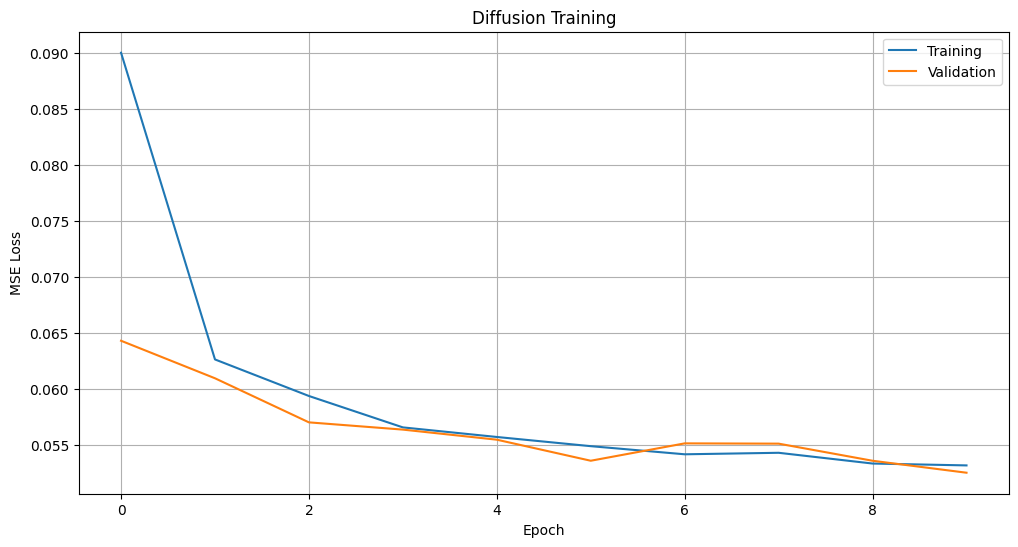

In [ ]:
plt.figure(figsize = (12, 6))

plt.plot(training_losses, label = "Training")
plt.plot(validation_losses, label = "Validation")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Diffusion Training")

plt.legend()
plt.grid()
plt.show()

## Generate Images

In [ ]:
generated_images = sample_cfg(
    ema_model,
    evaluation_prompts,
    guidance_scale = GUIDANCE_SCALE
)

CFG Sampling:   0%|          | 0/1000 [00:00<?, ?it/s]

## Displaying Generated Images

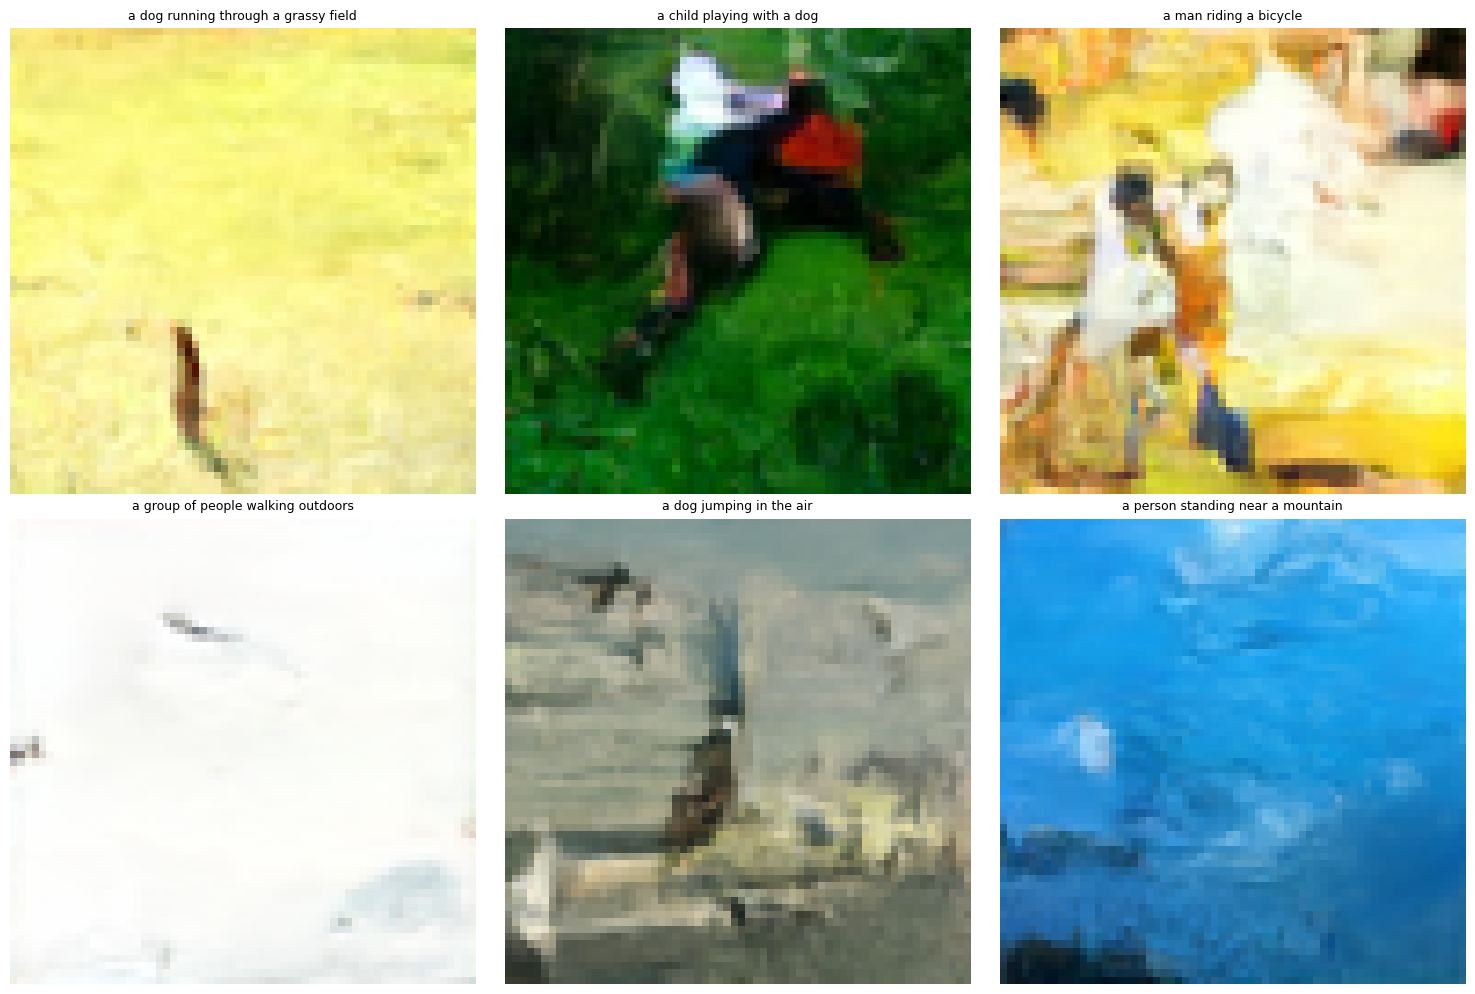

In [ ]:
fig, axes = plt.subplots(2, 3, figsize = (15, 10))

for ax, image, prompt in zip(axes.flatten(), generated_images, evaluation_prompts):

    image = image.detach().cpu().permute(1, 2, 0).numpy()

    ax.imshow(image)
    ax.set_title(prompt, fontsize = 9)
    ax.axis("off")

plt.tight_layout()
plt.show()

## Saving Generated Images

In [ ]:
for index, (image, prompt) in enumerate(zip(generated_images, evaluation_prompts)):

    filename = f"generated_{index}.png"

    path = os.path.join(
        GENERATED_DIR,
        filename
    )

    save_image(image, path)
    print(path)

/kaggle/working/generated_images/generated_0.png
/kaggle/working/generated_images/generated_1.png
/kaggle/working/generated_images/generated_2.png
/kaggle/working/generated_images/generated_3.png
/kaggle/working/generated_images/generated_4.png
/kaggle/working/generated_images/generated_5.png


## Custom Prompt

In [ ]:
custom_prompt = input("Enter image prompt: ")

Enter image prompt: dog


In [ ]:
custom_image = sample_cfg(
    ema_model,
    [custom_prompt],
    guidance_scale = GUIDANCE_SCALE
)[0]

CFG Sampling:   0%|          | 0/1000 [00:00<?, ?it/s]

## Displaying Custom Prompt Image

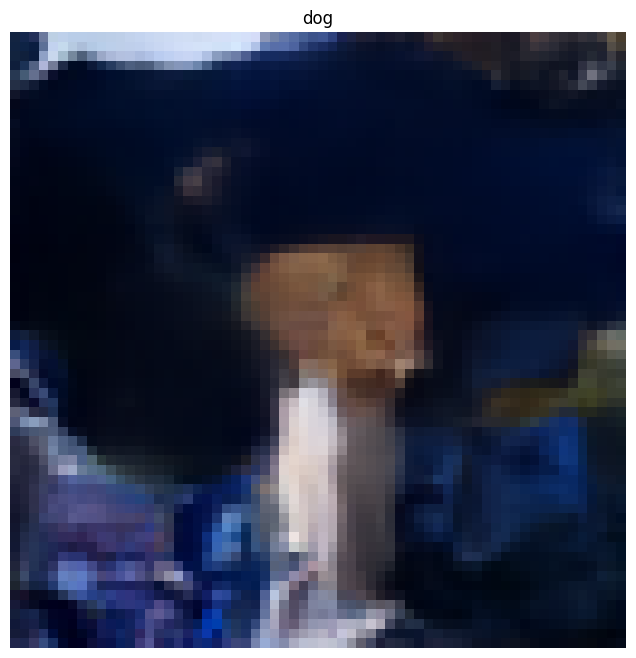

In [ ]:
custom_image_display = custom_image.detach().cpu().permute(1, 2, 0).numpy()

plt.figure(figsize = (8, 8))

plt.imshow(custom_image_display)
plt.title(custom_prompt)

plt.axis("off")
plt.show()

## Saving Final Model

In [ ]:
final_model_path = os.path.join(
    CHECKPOINT_DIR,
    "flickr8k_conditional_ddpm_final.pt"
)

torch.save(
    {
        "model_state_dict": model.state_dict(),
        "ema_state_dict": ema_model.state_dict(),
        "config": {
            "image_size": IMAGE_SIZE,
            "num_timesteps": NUM_TIMESTEPS,
            "base_channels": BASE_CHANNELS,
            "time_embed_dim": TIME_EMBED_DIM,
            "text_embed_dim": TEXT_EMBED_DIM,
            "max_text_length": MAX_TEXT_LENGTH
          }
    },
    final_model_path
)

print("Model Saved!")
print(final_model_path)

Model Saved!
/kaggle/working/diffusion_checkpoints/flickr8k_conditional_ddpm_final.pt


## Loading Final Model

In [ ]:
checkpoint = torch.load(
    final_model_path,
    map_location = device
)

loaded_model = ConditionalUNet(
    in_channels = 3,
    out_channels = 3,
    base_channels = checkpoint["config"]["base_channels"],
    time_dim = checkpoint["config"]["time_embed_dim"],
    text_dim = checkpoint["config"]["text_embed_dim"]
).to(device)

loaded_model.load_state_dict(checkpoint["ema_state_dict"])
loaded_model.eval()

print("Model Loaded!")

Model Loaded!


## Testing Final Prompt

In [ ]:
final_prompt = "a dog running through a field"

final_image = sample_cfg(
    loaded_model,
    [final_prompt],
    guidance_scale = GUIDANCE_SCALE
)[0]

CFG Sampling:   0%|          | 0/1000 [00:00<?, ?it/s]

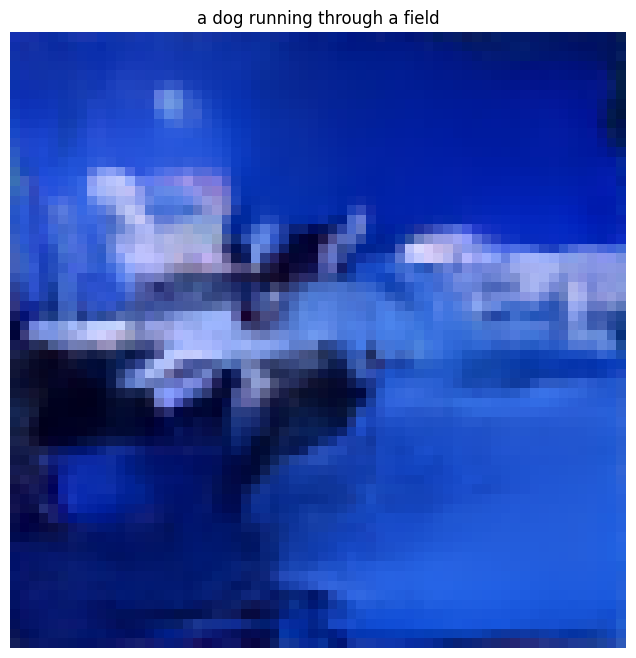

In [ ]:
final_image_display = final_image.detach().cpu().permute(1, 2, 0).numpy()

plt.figure(figsize = (8, 8))

plt.imshow(final_image_display)
plt.title(final_prompt)

plt.axis("off")
plt.show()

## Final Model Information

In [ ]:
print("Dataset: Flickr8k")
print("Training images:", len(train_images))
print("Training caption pairs:", len(train_df))
print("Validation images:", len(validation_images))
print("Image resolution:", IMAGE_SIZE, "x", IMAGE_SIZE)
print("Diffusion steps:", NUM_TIMESTEPS)
print("Text encoder:", CLIP_MODEL_NAME)
print("Guidance scale:", GUIDANCE_SCALE)
print("Model parameters:", f"{total_parameters:,}")

Dataset: Flickr8k
Training images: 7281
Training caption pairs: 36405
Validation images: 810
Image resolution: 64 x 64
Diffusion steps: 1000
Text encoder: openai/clip-vit-large-patch14
Guidance scale: 1.0
Model parameters: 21,990,083
